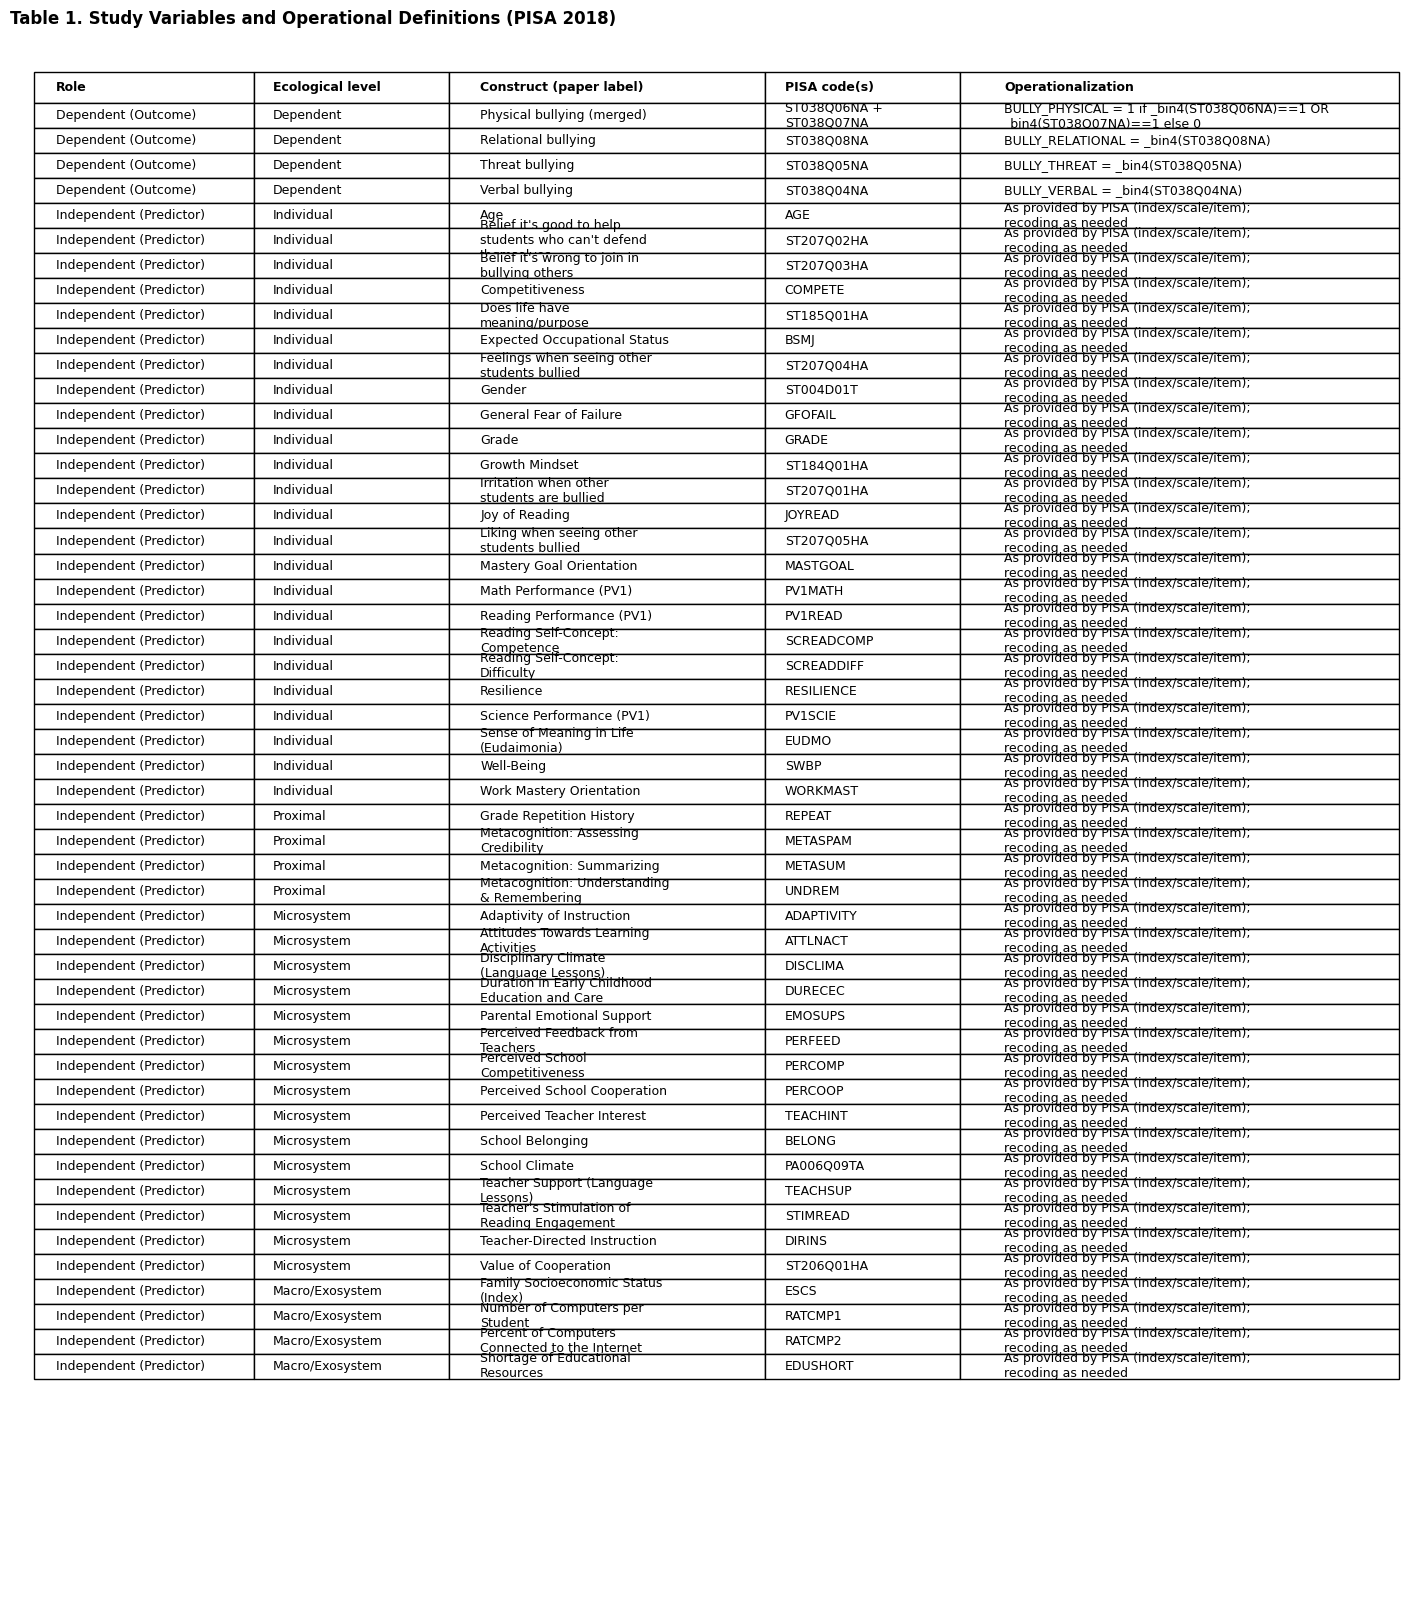

Saved:
- variables_table_pisa2018.csv
- variables_table_pisa2018.png
- variables_table_pisa2018.pdf


In [1]:
#variables table


# Visual "Table of Variables" generator
# Creates:
# 1) a clean DataFrame you can export (CSV)
# 2) a publication-ready TABLE FIGURE (PNG + PDF) using matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# -----------------------------
# 1) Define variables (from your lists)
# -----------------------------

predictors = [
    # Individual-level
    ("Individual", "Gender", "ST004D01T"),
    ("Individual", "Age", "AGE"),
    ("Individual", "Grade", "GRADE"),
    ("Individual", "Expected Occupational Status", "BSMJ"),
    ("Individual", "Joy of Reading", "JOYREAD"),
    ("Individual", "Reading Self-Concept: Competence", "SCREADCOMP"),
    ("Individual", "Reading Self-Concept: Difficulty", "SCREADDIFF"),
    ("Individual", "Competitiveness", "COMPETE"),
    ("Individual", "Work Mastery Orientation", "WORKMAST"),
    ("Individual", "General Fear of Failure", "GFOFAIL"),
    ("Individual", "Sense of Meaning in Life (Eudaimonia)", "EUDMO"),
    ("Individual", "Resilience", "RESILIENCE"),
    ("Individual", "Mastery Goal Orientation", "MASTGOAL"),
    ("Individual", "Does life have meaning/purpose", "ST185Q01HA"),
    ("Individual", "Growth Mindset", "ST184Q01HA"),
    ("Individual", "Well-Being", "SWBP"),
    ("Individual", "Math Performance (PV1)", "PV1MATH"),
    ("Individual", "Reading Performance (PV1)", "PV1READ"),
    ("Individual", "Science Performance (PV1)", "PV1SCIE"),
    ("Individual", "Irritation when other students are bullied", "ST207Q01HA"),
    ("Individual", "Belief it's good to help students who can't defend themselves", "ST207Q02HA"),
    ("Individual", "Belief it's wrong to join in bullying others", "ST207Q03HA"),
    ("Individual", "Feelings when seeing other students bullied", "ST207Q04HA"),
    ("Individual", "Liking when seeing other students bullied", "ST207Q05HA"),

    # Proximal-level
    ("Proximal", "Grade Repetition History", "REPEAT"),
    ("Proximal", "Metacognition: Understanding & Remembering", "UNDREM"),
    ("Proximal", "Metacognition: Summarizing", "METASUM"),
    ("Proximal", "Metacognition: Assessing Credibility", "METASPAM"),

    # Microsystem-level
    ("Microsystem", "Parental Emotional Support", "EMOSUPS"),
    ("Microsystem", "Duration in Early Childhood Education and Care", "DURECEC"),
    ("Microsystem", "School Belonging", "BELONG"),
    ("Microsystem", "Perceived School Competitiveness", "PERCOMP"),
    ("Microsystem", "Perceived School Cooperation", "PERCOOP"),
    ("Microsystem", "Attitudes Towards Learning Activities", "ATTLNACT"),
    ("Microsystem", "Disciplinary Climate (Language Lessons)", "DISCLIMA"),
    ("Microsystem", "Teacher Support (Language Lessons)", "TEACHSUP"),
    ("Microsystem", "Teacher-Directed Instruction", "DIRINS"),
    ("Microsystem", "Perceived Feedback from Teachers", "PERFEED"),
    ("Microsystem", "Teacher's Stimulation of Reading Engagement", "STIMREAD"),
    ("Microsystem", "Adaptivity of Instruction", "ADAPTIVITY"),
    ("Microsystem", "Perceived Teacher Interest", "TEACHINT"),
    ("Microsystem", "Value of Cooperation", "ST206Q01HA"),
    ("Microsystem", "School Climate", "PA006Q09TA"),

    # Macro/Exosystem-level
    ("Macro/Exosystem", "Family Socioeconomic Status (Index)", "ESCS"),
    ("Macro/Exosystem", "Shortage of Educational Resources", "EDUSHORT"),
    ("Macro/Exosystem", "Number of Computers per Student", "RATCMP1"),
    ("Macro/Exosystem", "Percent of Computers Connected to the Internet", "RATCMP2"),
]

# Dependent variables (bullying types)
# Physical is merged: ST038Q06NA OR ST038Q07NA after binarization
dvs = [
    ("Dependent", "Verbal bullying", "BULLY_VERBAL", "ST038Q04NA", "BULLY_VERBAL = _bin4(ST038Q04NA)"),
    ("Dependent", "Threat bullying", "BULLY_THREAT", "ST038Q05NA", "BULLY_THREAT = _bin4(ST038Q05NA)"),
    ("Dependent", "Relational bullying", "BULLY_RELATIONAL", "ST038Q08NA", "BULLY_RELATIONAL = _bin4(ST038Q08NA)"),
    ("Dependent", "Physical bullying (merged)", "BULLY_PHYSICAL", "ST038Q06NA + ST038Q07NA",
     "BULLY_PHYSICAL = 1 if _bin4(ST038Q06NA)==1 OR _bin4(ST038Q07NA)==1 else 0"),
]

# -----------------------------
# 2) Build one combined table
# -----------------------------
rows = []

# predictors
for level, construct, code in predictors:
    rows.append({
        "Role": "Independent (Predictor)",
        "Ecological level": level,
        "Construct (paper label)": construct,
        "PISA code(s)": code,
        "Operationalization": "As provided by PISA (index/scale/item); recoding as needed"
    })

# DVs
for level, construct, dv_name, code, op in dvs:
    rows.append({
        "Role": "Dependent (Outcome)",
        "Ecological level": level,
        "Construct (paper label)": construct,
        "PISA code(s)": code,
        "Operationalization": op
    })

df = pd.DataFrame(rows)

# Optional: sort nicely
level_order = {
    "Dependent": 0,
    "Individual": 1,
    "Proximal": 2,
    "Microsystem": 3,
    "Macro/Exosystem": 4
}
df["__level_order"] = df["Ecological level"].map(level_order).fillna(99).astype(int)
df["__role_order"] = df["Role"].map({"Dependent (Outcome)": 0, "Independent (Predictor)": 1}).fillna(9).astype(int)
df = df.sort_values(["__role_order", "__level_order", "Construct (paper label)"]).drop(columns=["__level_order", "__role_order"])

# Save a machine-readable copy for your appendix/supplement
df.to_csv("variables_table_pisa2018.csv", index=False)

# -----------------------------
# 3) Render as a publication-style TABLE FIGURE (PNG/PDF)
# -----------------------------
def wrap_col(series, width):
    return series.apply(lambda s: "\n".join(textwrap.wrap(str(s), width=width)) if pd.notna(s) else "")

df_vis = df.copy()
df_vis["Construct (paper label)"] = wrap_col(df_vis["Construct (paper label)"], 28)
df_vis["Operationalization"] = wrap_col(df_vis["Operationalization"], 45)
df_vis["PISA code(s)"] = wrap_col(df_vis["PISA code(s)"], 18)

cols = ["Role", "Ecological level", "Construct (paper label)", "PISA code(s)", "Operationalization"]
cell_text = df_vis[cols].values.tolist()
col_labels = cols

# Figure size scales with number of rows
n_rows = len(df_vis)
fig_h = max(8, 0.32 * n_rows)   # adjust 0.32 up/down if needed
fig_w = 14

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="left",
    colLoc="left",
    loc="upper left"
)

# Style
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.2)

# Column width tuning (sum doesn't need to be 1, matplotlib is flexible)
col_widths = [0.18, 0.16, 0.26, 0.16, 0.36]
for (r, c), cell in table.get_celld().items():
    # header row
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(cell.get_height() * 1.25)
    # set widths
    if c < len(col_widths):
        cell.set_width(col_widths[c])

# Title like a paper
title = "Table 1. Study Variables and Operational Definitions (PISA 2018)"
ax.set_title(title, fontsize=12, fontweight="bold", loc="left", pad=12)

plt.tight_layout()

# Export figure
plt.savefig("variables_table_pisa2018.png", dpi=300, bbox_inches="tight")
plt.savefig("variables_table_pisa2018.pdf", bbox_inches="tight")
plt.show()

print("Saved:")
print("- variables_table_pisa2018.csv")
print("- variables_table_pisa2018.png")
print("- variables_table_pisa2018.pdf")


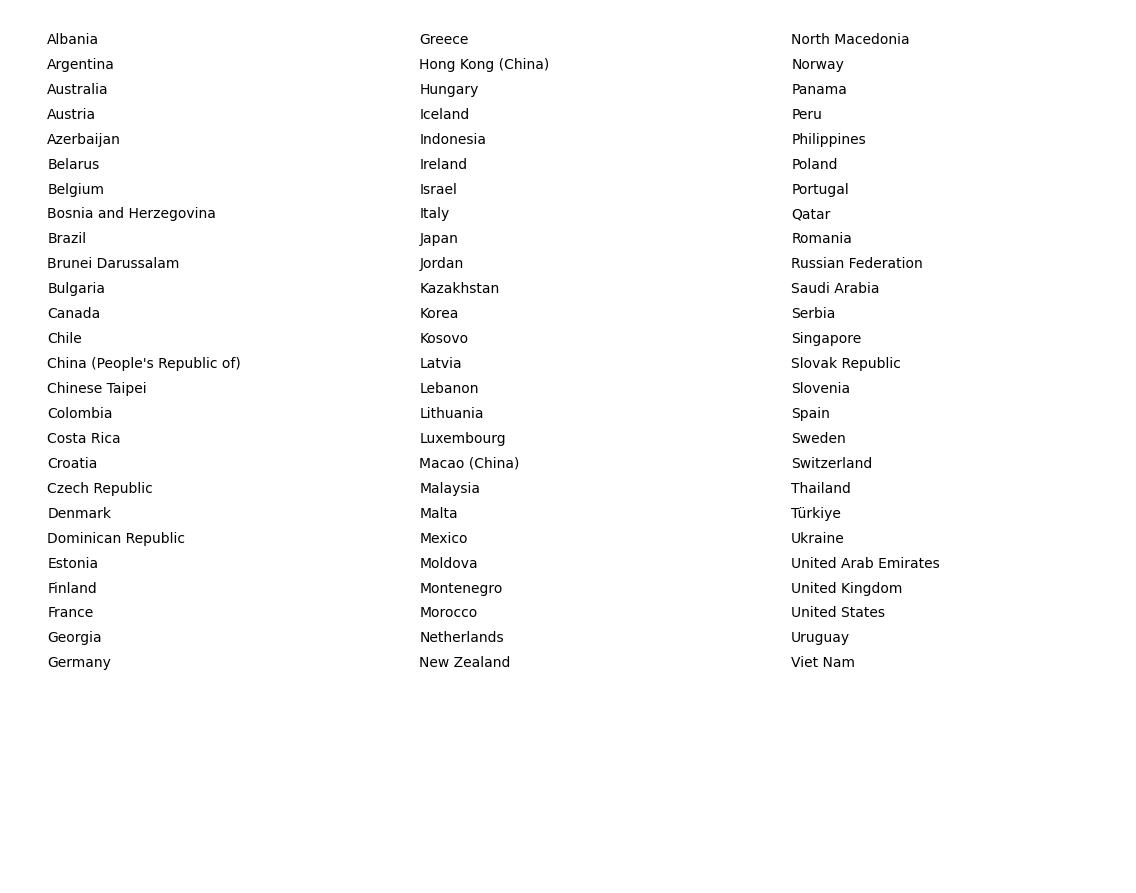

In [4]:
import matplotlib.pyplot as plt
import math

countries_2018 = [
    "Albania","Argentina","Australia","Austria","Azerbaijan","Belarus","Belgium",
    "Bosnia and Herzegovina","Brazil","Brunei Darussalam","Bulgaria","Canada",
    "Chile","China (People's Republic of)","Chinese Taipei","Colombia",
    "Costa Rica","Croatia","Czech Republic","Denmark","Dominican Republic",
    "Estonia","Finland","France","Georgia","Germany","Greece",
    "Hong Kong (China)","Hungary","Iceland","Indonesia","Ireland","Israel",
    "Italy","Japan","Jordan","Kazakhstan","Korea","Kosovo","Latvia","Lebanon",
    "Lithuania","Luxembourg","Macao (China)","Malaysia","Malta","Mexico",
    "Moldova","Montenegro","Morocco","Netherlands","New Zealand",
    "North Macedonia","Norway","Panama","Peru","Philippines","Poland",
    "Portugal","Qatar","Romania","Russian Federation","Saudi Arabia","Serbia",
    "Singapore","Slovak Republic","Slovenia","Spain","Sweden","Switzerland",
    "Thailand","Türkiye","Ukraine","United Arab Emirates","United Kingdom",
    "United States","Uruguay","Viet Nam"
]

countries_2018 = sorted(countries_2018)

# ---- Layout ----
n_cols = 3
n_rows = math.ceil(len(countries_2018) / n_cols)

countries_padded = countries_2018 + [""] * (n_rows * n_cols - len(countries_2018))

table_data = []
for row in range(n_rows):
    table_row = []
    for col in range(n_cols):
        table_row.append(countries_padded[col * n_rows + row])
    table_data.append(table_row)

# ---- Dynamic height calculation ----
row_height = 0.35
fig_height = n_rows * row_height

fig, ax = plt.subplots(figsize=(12, fig_height))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    loc='upper center',   # <-- pushes table upward
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Remove borders
for cell in table.get_celld().values():
    cell.set_linewidth(0)

# Tight layout removes white space
plt.subplots_adjust(top=0.98, bottom=0.02)

plt.savefig("PISA_2018_Countries_Table_clean.png", dpi=300, bbox_inches='tight')
plt.savefig("PISA_2018_Countries_Table_clean.pdf", bbox_inches='tight')

plt.show()


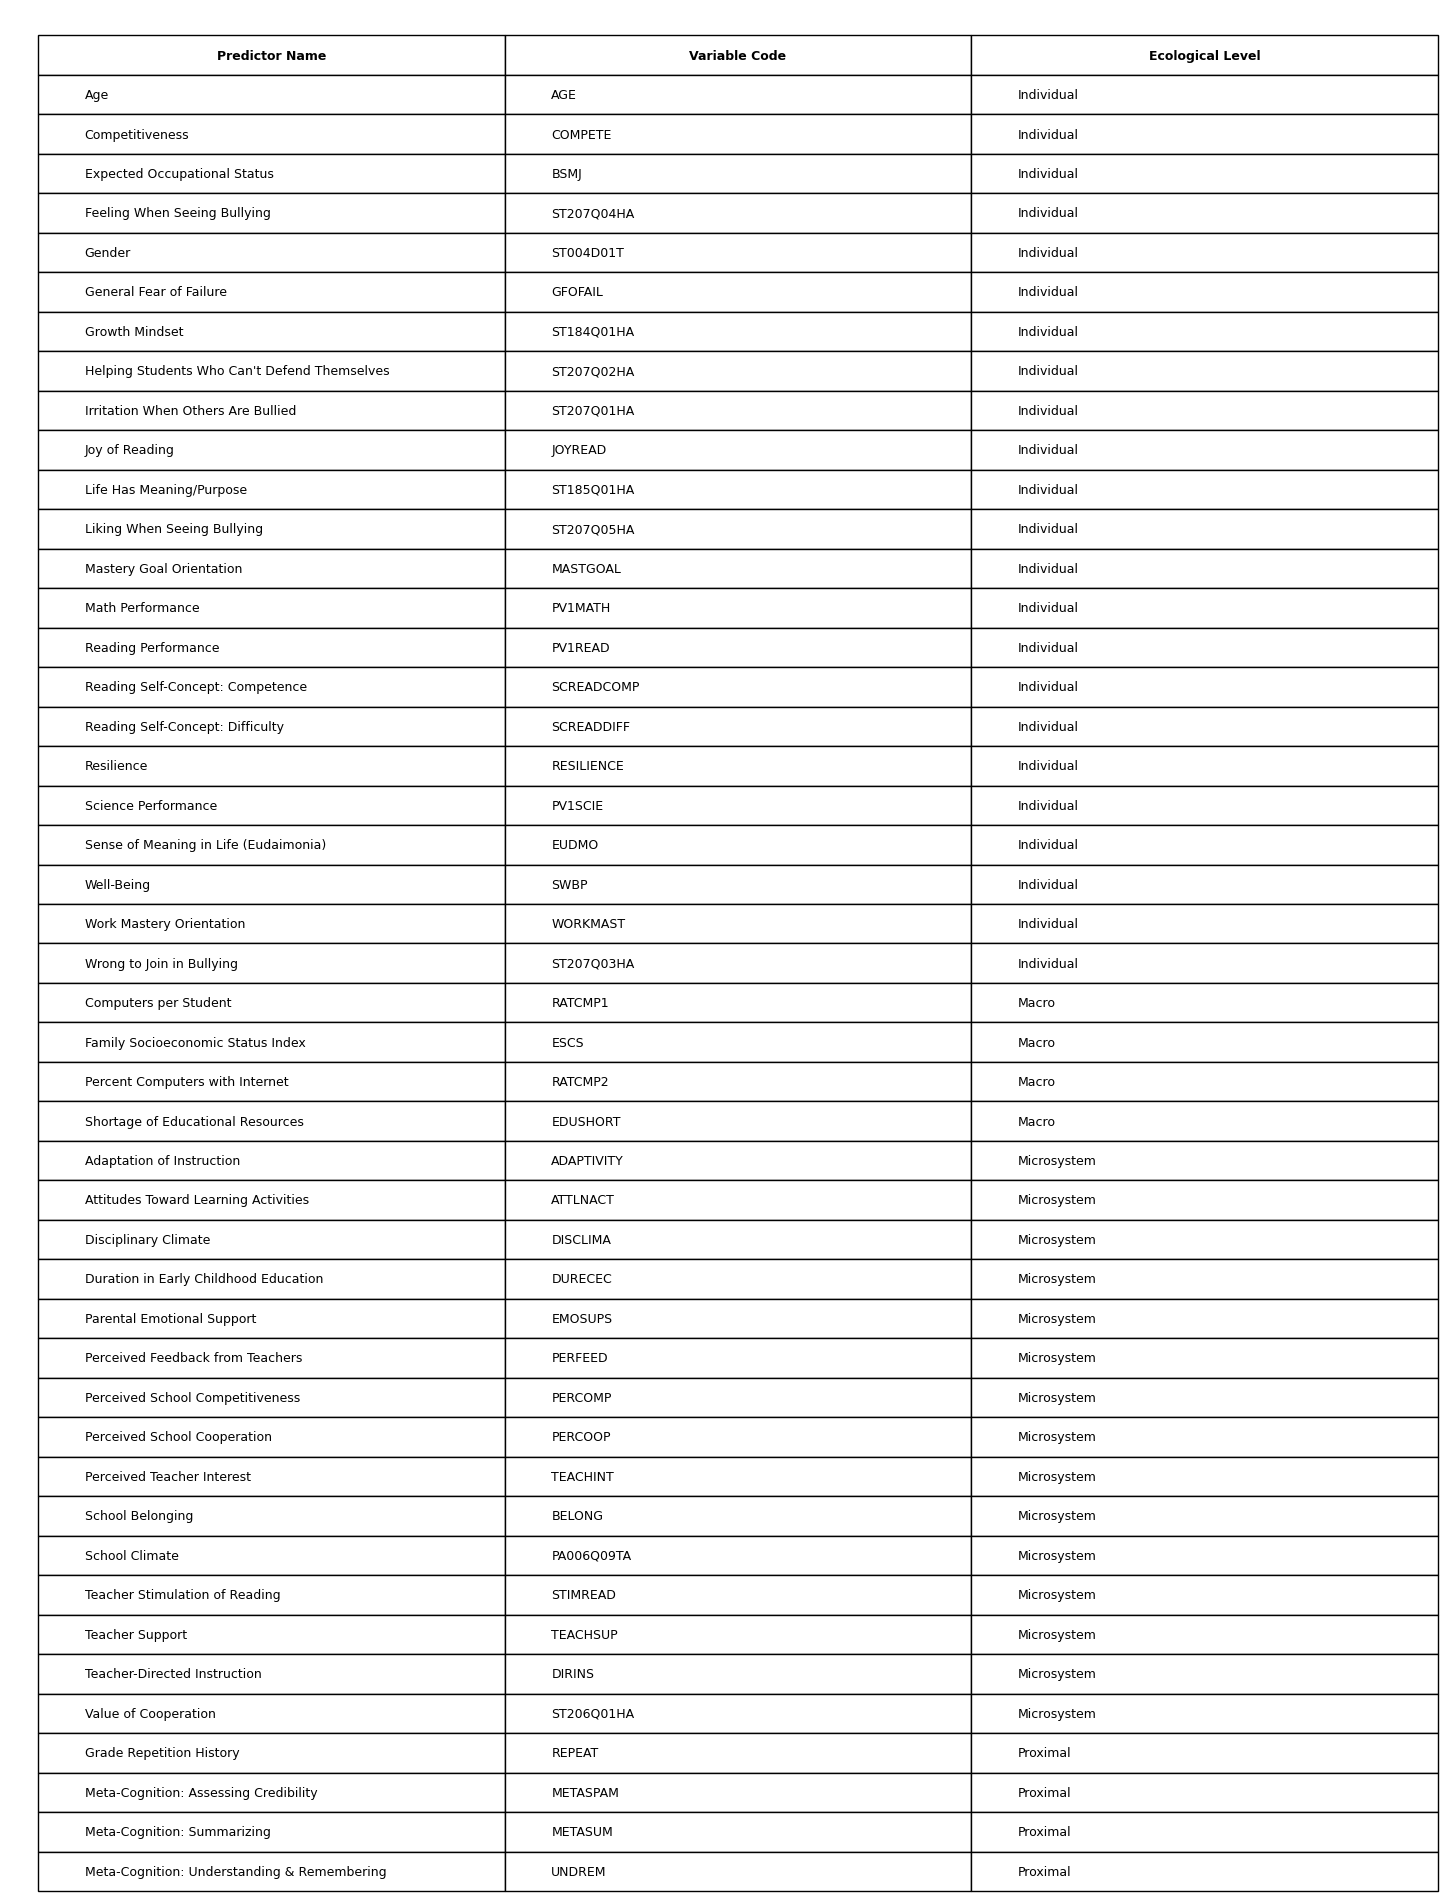

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Data
# ----------------------------

data = [
    # Individual
    ("Age", "AGE", "Individual"),
    ("Competitiveness", "COMPETE", "Individual"),
    ("Expected Occupational Status", "BSMJ", "Individual"),
    ("Feeling When Seeing Bullying", "ST207Q04HA", "Individual"),
    ("Gender", "ST004D01T", "Individual"),
    ("General Fear of Failure", "GFOFAIL", "Individual"),
    ("Growth Mindset", "ST184Q01HA", "Individual"),
    ("Helping Students Who Can't Defend Themselves", "ST207Q02HA", "Individual"),
    ("Irritation When Others Are Bullied", "ST207Q01HA", "Individual"),
    ("Joy of Reading", "JOYREAD", "Individual"),
    ("Life Has Meaning/Purpose", "ST185Q01HA", "Individual"),
    ("Liking When Seeing Bullying", "ST207Q05HA", "Individual"),
    ("Mastery Goal Orientation", "MASTGOAL", "Individual"),
    ("Math Performance", "PV1MATH", "Individual"),
    ("Reading Performance", "PV1READ", "Individual"),
    ("Reading Self-Concept: Competence", "SCREADCOMP", "Individual"),
    ("Reading Self-Concept: Difficulty", "SCREADDIFF", "Individual"),
    ("Resilience", "RESILIENCE", "Individual"),
    ("Science Performance", "PV1SCIE", "Individual"),
    ("Sense of Meaning in Life (Eudaimonia)", "EUDMO", "Individual"),
    ("Well-Being", "SWBP", "Individual"),
    ("Work Mastery Orientation", "WORKMAST", "Individual"),
    ("Wrong to Join in Bullying", "ST207Q03HA", "Individual"),

    # Macro
    ("Computers per Student", "RATCMP1", "Macro"),
    ("Family Socioeconomic Status Index", "ESCS", "Macro"),
    ("Percent Computers with Internet", "RATCMP2", "Macro"),
    ("Shortage of Educational Resources", "EDUSHORT", "Macro"),

    # Microsystem
    ("Adaptation of Instruction", "ADAPTIVITY", "Microsystem"),
    ("Attitudes Toward Learning Activities", "ATTLNACT", "Microsystem"),
    ("Disciplinary Climate", "DISCLIMA", "Microsystem"),
    ("Duration in Early Childhood Education", "DURECEC", "Microsystem"),
    ("Parental Emotional Support", "EMOSUPS", "Microsystem"),
    ("Perceived Feedback from Teachers", "PERFEED", "Microsystem"),
    ("Perceived School Competitiveness", "PERCOMP", "Microsystem"),
    ("Perceived School Cooperation", "PERCOOP", "Microsystem"),
    ("Perceived Teacher Interest", "TEACHINT", "Microsystem"),
    ("School Belonging", "BELONG", "Microsystem"),
    ("School Climate", "PA006Q09TA", "Microsystem"),
    ("Teacher Support", "TEACHSUP", "Microsystem"),
    ("Teacher Stimulation of Reading", "STIMREAD", "Microsystem"),
    ("Teacher-Directed Instruction", "DIRINS", "Microsystem"),
    ("Value of Cooperation", "ST206Q01HA", "Microsystem"),

    # Proximal
    ("Grade Repetition History", "REPEAT", "Proximal"),
    ("Meta-Cognition: Assessing Credibility", "METASPAM", "Proximal"),
    ("Meta-Cognition: Summarizing", "METASUM", "Proximal"),
    ("Meta-Cognition: Understanding & Remembering", "UNDREM", "Proximal"),
]

df = pd.DataFrame(data, columns=["Predictor Name", "Variable Code", "Ecological Level"])

# Order categories
level_order = ["Individual", "Macro", "Microsystem", "Proximal"]
df["Ecological Level"] = pd.Categorical(df["Ecological Level"], categories=level_order, ordered=True)
df = df.sort_values(["Ecological Level", "Predictor Name"]).reset_index(drop=True)

# ----------------------------
# Perfect Height Calculation
# ----------------------------

rows = len(df) + 1  # +1 header
row_height = 0.28
fig_height = rows * row_height

fig = plt.figure(figsize=(14, fig_height))
ax = fig.add_axes([0, 0, 1, 1])  # Full canvas
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='left',
    loc='upper left'
)

table.auto_set_font_size(False)
table.set_fontsize(9)

# Adjust row height manually
for (row, col), cell in table.get_celld().items():
    cell.set_height(0.03)
    if row == 0:
        cell.set_text_props(weight='bold')

# Remove margins completely
plt.margins(0, 0)

# Save tightly
plt.savefig("Predictor_Table_Grouped.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.savefig("Predictor_Table_Grouped.pdf", bbox_inches='tight', pad_inches=0)

plt.show()
